In [162]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score, classification_report
from yellowbrick.cluster import KElbowVisualizer
import pickle
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score, precision_score, recall_score, f1_score,accuracy_score, confusion_matrix


### Sistema de agrupación de casas

Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

En este caso solo nos interesan las columnas Latitude, Longitude y MedInc

In [163]:
df =  pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/internal-link-nosupervisado.csv')

## EDA

In [164]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [166]:
df.drop_duplicates(inplace=True)

In [167]:
df.drop(columns=['HouseAge','AveRooms',	'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], inplace= True)

In [168]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


Elimino las columnas que el enunciado me indica que no debo utilizar. 

In [169]:
x = df

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

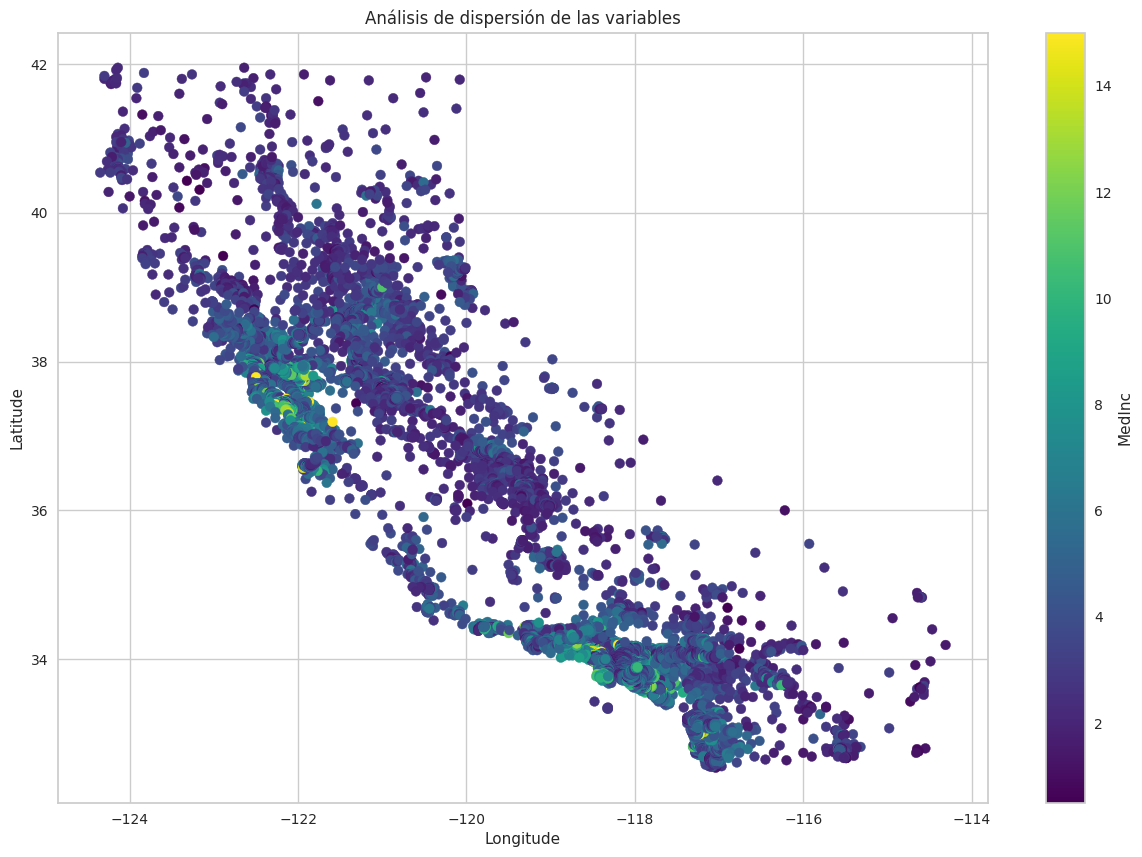

In [170]:
plt.figure(figsize=(15,10))
plt.scatter(df['Longitude'], df['Latitude'], c=df['MedInc'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='MedInc')
plt.title('Análisis de dispersión de las variables')
plt.show()

### Slipt.

In [171]:
X_train, X_test = train_test_split(x, test_size=0.2, random_state=42, shuffle=True)
X_train.shape, X_test.shape

((16512, 3), (4128, 3))

### Escalado.

In [172]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [173]:
X_train_scaled

array([[0.19032151, 0.01702128, 0.72908367],
       [0.22845202, 0.12978723, 0.61653386],
       [0.25216204, 0.22446809, 0.38545817],
       ...,
       [0.16789424, 0.15744681, 0.59462151],
       [0.35994676, 0.53510638, 0.23804781],
       [0.14314285, 0.55531915, 0.19223108]])

In [174]:
with open('../models/scaler_kmeans.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### Modelado. 

In [175]:
kmeans = KMeans(n_clusters=6, random_state=18, n_init=10)

In [176]:
clusters = kmeans.fit_predict(X_train_scaled)

In [177]:
silhouette_score(X_train_scaled, kmeans.labels_)

0.3962707689433098

In [178]:
df.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [179]:
clusters

array([4, 4, 0, ..., 4, 3, 5], dtype=int32)

In [180]:
df_clusters = X_train.copy()
df_clusters["clusters"] = clusters

In [181]:
df_clusters.head()

,MedInc,Latitude,Longitude,clusters
14196,3.2596,32.71,-117.03,4
8267,3.8125,33.77,-118.16,4
17445,4.1563,34.66,-120.48,0
14265,1.9425,32.69,-117.11,4
2271,3.5542,36.78,-119.80,0


In [182]:
test_clusters = kmeans.predict(X_test_scaled)
df_clusters_test = X_test.copy()
df_clusters_test["cluster"] = test_clusters

In [183]:
df_clusters_test

,MedInc,Latitude,Longitude,cluster
20046,1.6812,36.06,-119.01,0
3024,2.5313,35.14,-119.46,0
15663,3.4801,37.80,-122.44,5
20484,5.7376,34.28,-118.72,1
9814,3.7250,36.62,-121.93,5
...,...,...,...,...
15362,4.6050,33.36,-117.22,4
16623,2.7266,35.36,-120.83,0
18086,9.2298,37.31,-122.05,3
2144,2.7850,36.77,-119.76,0


## Segundo Slipt.

In [184]:
X_train_clus = X_train_scaled
y_train_clus = clusters 

In [185]:

X_test_clus = X_test_scaled
y_test_clus = test_clusters

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

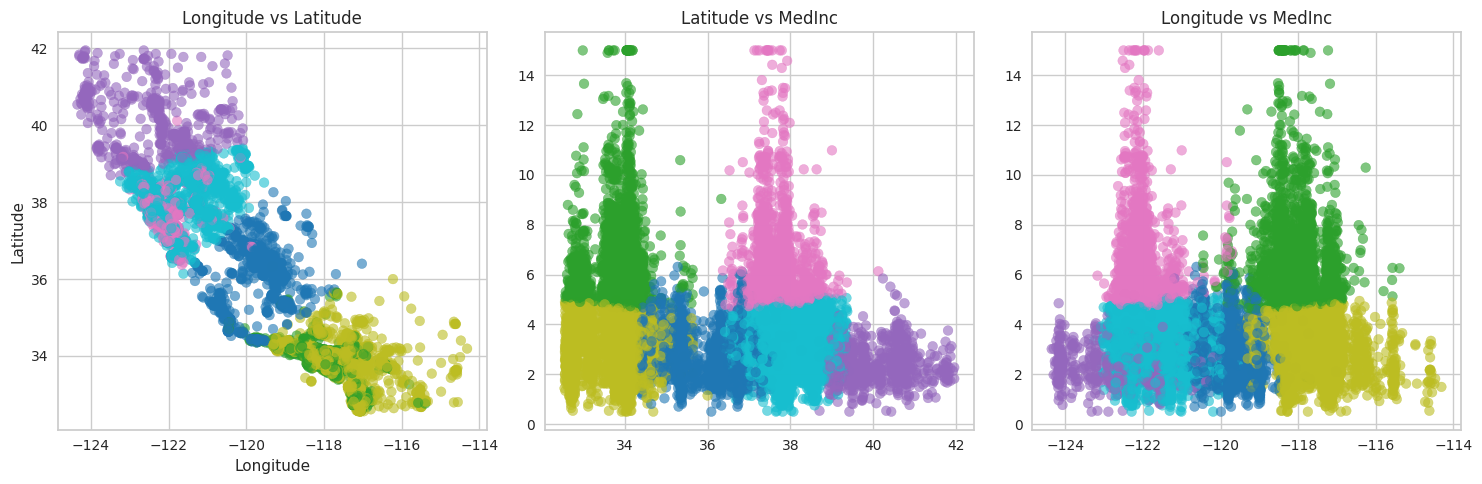

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df_clusters['Longitude'], df_clusters['Latitude'], c=df_clusters['clusters'], cmap='tab10', alpha=0.6)
axes[0].set_title('Longitude vs Latitude')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[1].scatter(df_clusters['Latitude'], df_clusters['MedInc'], c=df_clusters['clusters'], cmap='tab10', alpha=0.6)
axes[1].set_title('Latitude vs MedInc')
axes[2].scatter(df_clusters['Longitude'], df_clusters['MedInc'], c=df_clusters['clusters'], cmap='tab10', alpha=0.6)
axes[2].set_title('Longitude vs MedInc')

plt.tight_layout()
plt.show()

In [187]:
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

### Modelado. 

In [188]:
model_tree = DecisionTreeClassifier(random_state=18, max_depth=5, min_samples_split=10)
model_tree.fit(X_train_clus, y_train_clus)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [189]:
y_pred = model_tree.predict(X_test_clus)
y_pred

array([0, 0, 5, ..., 3, 0, 4], dtype=int32)

In [190]:
metricas = classification_report(y_test_clus, y_pred, output_dict=True)
df_metricas = pd.DataFrame(metricas)
df_metricas

,0,1,2,3,4,5,accuracy,macro avg,weighted avg
precision,0.978788,0.976783,0.878307,0.988889,0.995838,0.979253,0.981831,0.966310,0.982102
recall,0.969970,0.993255,0.927374,0.983425,0.993476,0.968205,0.981831,0.972618,0.981831
f1-score,0.974359,0.984950,0.902174,0.986150,0.994656,0.973698,0.981831,0.969331,0.981918
support,333.000000,593.000000,179.000000,362.000000,1686.000000,975.000000,0.981831,4128.000000,4128.000000


In [191]:
model_tree.score(X_test_clus, y_test_clus)

0.9818313953488372

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

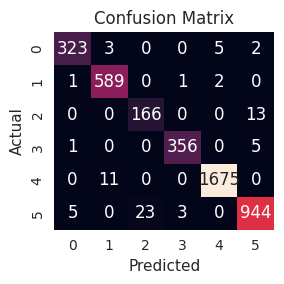

In [192]:
df_confusion = confusion_matrix(y_test_clus, y_pred)
df_cm = pd.DataFrame(df_confusion)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()

In [193]:
with open('/workspaces/Antonio27M-machine-learning/models/modelado-DecisionTreeClassifier.pkl', 'wb') as file:
    pickle.dump(model_tree, file)

### Conclusiones: 

Al comenzar el análisis del modelo kmeans el resultado del silhouette_score me refleja un 0.39 muy alejado del 1 positivo por lo cual los 'clausters' contienen una agrupación débil por ende hay que reconfigurar las métricas del modelo, pero no se hace ninguna reconfiguración adicional por el enunciado de la academia a mantenerse fiel a la agrupación de 6.

Se tiene que hacer escalado general para luego aplicar el slipt con nuestra target que sea los 'clausters' para luego este caso aplicar árbol de decisión con un resultado de predicción del 98%.